In [1]:
# Based on simulation 1: create a simulation where the RCT is not included in the observational study in 
# terms of X and show performance of the model

import numpy as np
import pandas as pd
from scipy.stats import bernoulli, norm

def data_simulation(sample_size_rct, sample_size_obs):
    """
    Simulate observational and trial data according to a specified logistic participation model.\
    

        Confounding: Complex
        Y(0): Complex
        Y(1): Complex
        CATE: Complex


    Parameters:
    sample_size : int
        Number of samples to generate.
    beta0 : float
        Intercept parameter of the logistic participation model.
    beta1 : float
        Slope parameter of the logistic participation model.

    Returns:
    data_trial : numpy.ndarray
        Simulated trial data containing columns for participation indicator (S), covariate (X), treatment assignment (A), and outcome (Y).
    data_observation : numpy.ndarray
        Simulated observational data containing columns for participation indicator (S), covariate (X), treatment assignment (A), and outcome (Y).
    """

    

    X_trial = np.random.uniform(-2, 0, sample_size_rct)
    S_trial = np.ones(X_trial.shape[0])
    
    A_trial = bernoulli.rvs(0.5, size=np.shape(X_trial)[0])
    tau_X_trial = 1 + X_trial + X_trial**2
    epsilon_trial = norm.rvs(0, 1.0, np.shape(X_trial)[0])
    Y_trial = A_trial * tau_X_trial + X_trial**2 - 1 + epsilon_trial

    X_observational = np.random.uniform(-2, 2, sample_size_obs)
    S_observational = np.zeros(X_observational.shape[0])
    logit_e_X_0 = X_observational
    A_observational = bernoulli.rvs(1 / (1 + np.exp(-logit_e_X_0)), size=np.shape(X_observational)[0])
    tau_X_observational = 1 + X_observational + X_observational**2
    U_observational = (2 * A_observational - 1) *np.sin(X_observational-1) + norm.rvs(0, 1, size=np.shape(X_observational)[0])
    epsilon_observational = norm.rvs(0, 1, size=np.shape(X_observational)[0])
    Y_observational = A_observational * tau_X_observational + X_observational**2 - 1 + U_observational + epsilon_observational

    # Create DataFrames
    data_trial = np.column_stack((S_trial, X_trial, A_trial, Y_trial))
    
    data_observation = np.column_stack((S_observational, X_observational, A_observational, Y_observational))

    return data_trial, data_observation

In [2]:
data_exp, data_obs = data_simulation(sample_size_rct=200, sample_size_obs=1000)

In [3]:
# Model training 

import GPy
import numpy as np

def ICM(X_E, X_O, T_E, T_O, Y_E, Y_O, r, ID, AD, rho):
    """
    Train and return two rank-2 ICMs
    Args:
    - X_E (numpy.ndarray): Baseline covariate in the experimental data.
    - X_O (numpy.ndarray): Baseline covariate in the observational data.
    - T_E (numpy.ndarray): Treatment indicator in the experimental data.
    - T_O (numpy.ndarray): Treatment indicator in the observational data.
    - Y_E (numpy.ndarray): Outcome in the experimental data.
    - Y_O (numpy.ndarray): Outcome in the observational data.
    - r (int): Rank of the model.
    - ID (int): input dim
    - AD (list): active dim
    - rho: trust hyperparameter

    Returns:
    GPy.models.GPRegression: Trained Gaussian Process Regression model using Intrinsic Coregionalized Model (ICM).

    Data Processing:
    - Split the variables into treated and control for both observational and experimental data.

    Model Training:
    - Intrinsic Coregionalized Model (ICM) with a Radial Basis Function (RBF) kernel is used for regression.
    - The model is trained using Gaussian Process Regression.

    Note:
    - The order of arranging data matters: Experimental control, Observational control, Experimental treated, Observational treated.
    - An indicator is added to the baseline covariate to represent the task (0 for experimental control, 1 for observational control, 2 for experimental treated, 3 for observational treated).
    """

    # Data preprocessing
    # Split the variables in treated and control 
    # Observational Data
    X0_obs = X_O[T_O==0] # baseline covariate in th control arm of the observational study
    X1_obs = X_O[T_O==1] # baseline covariate in th treatment arm of the observational study
    Y0_obs = Y_O[T_O==0] # outcomee in th control arm of the observational study
    Y1_obs = Y_O[T_O==1] # outcomee in th treatment arm of the observational study
    
    #Exoerimental data
    X0_exp = X_E[T_E==0] # baseline covariate in th control arm of the experimental study
    X1_exp = X_E[T_E==1] # baseline covariate in th treatment arm of the experimental study
    Y0_exp = Y_E[T_E==0] # outcomee in th control arm of the experimental study
    Y1_exp = Y_E[T_E==1] # outcomee in th treatment arm of the experimental study
    

    # The order we arrange the data matters
    # 1. Experimental control
    # 2. Observational control
    # 3. Experimental treated
    # 4. Observational treated
    # We also need to add an indicator to the baseline covariate indicating the task
    # i.e. 0 is for the experiemental control, 1 is for the observational control,
    # 2 is for the experiemental treated, 3 is for observational treated
    X0_exp = np.c_[X0_exp,np.ones(X0_exp.shape[0])*0] 
    X0_obs = np.c_[X0_obs,np.ones(X0_obs.shape[0])*1]
    X1_exp = np.c_[X1_exp,np.ones(X1_exp.shape[0])*0]
    X1_obs = np.c_[X1_obs,np.ones(X1_obs.shape[0])*1]

    # Put all the data on a single array 
    Y0 = np.r_[Y0_exp, Y0_obs]
    X0 = np.r_[X0_exp, X0_obs]
    Y1 = np.r_[Y1_exp, Y1_obs]
    X1 = np.r_[X1_exp, X1_obs]


    # model training
    
    # Define the kernel
    kern = GPy.kern.RBF(input_dim=ID, active_dims = AD)**GPy.kern.Coregionalize(input_dim = 1, output_dim = 2, rank=r)
    # Define the model
    m0 = GPy.models.GPRegression(X0,np.vstack(Y0),kern)
    ##############################################################
    # Put all your constraines here
    m0.mul.coregion.W[0,0:1].fix(1)
    m0.mul.coregion.W[0,1:].fix(0)
    m0.mul.coregion.W[1,0:1].fix(rho)
    m0.mul.coregion.W[1,1:].fix(np.sqrt(1-rho**2))
    m0.mul.coregion.kappa.fix([0.000000001, 0.000000001])
    #m0.mul.rbf.variance.constrain_bounded(0., 10.)
    
    ##############################################################
    

    # Optimize the model
    m0.optimize()

    # Define the kernel
    kern = GPy.kern.RBF(input_dim=ID, active_dims = AD)**GPy.kern.Coregionalize(input_dim = 1, output_dim = 2, rank=r)
    # Define the model
    m1 = GPy.models.GPRegression(X1,np.vstack(Y1),kern)
    ##############################################################
    # Put all your constraines here
    m1.mul.coregion.W[0,0:1].fix(1)
    m1.mul.coregion.W[0,1:].fix(0)
    m1.mul.coregion.W[1,0:1].fix(rho)
    m1.mul.coregion.W[1,1:].fix(np.sqrt(1-rho**2))
    m1.mul.coregion.kappa.fix([0.000000001, 0.000000001])
    #m1.mul.rbf.variance.constrain_bounded(0., 10.)

    ##############################################################
    # Optimize the model
    
    m1.optimize()

    return m0, m1

In [4]:
import numpy as np
def weighted_mean_squared_error(weight, t, y_true, y_pred0, y_pred1):
    # Ensure inputs are numpy arrays
    y_true = np.hstack(y_true)
    y_pred0 = np.hstack(y_pred0)
    y_pred1 = np.hstack(y_pred1)
    weight = np.hstack(weight)
    weighted_squared_diff = np.zeros(y_true.shape[0])
    weighted_squared_diff[t==0] = weight[t==0]*((y_true[t==0] - y_pred0[t==0])**2) 
    weighted_squared_diff[t==1] = weight[t==1]*((y_true[t==1] - y_pred1[t==1])**2)  
    wmse = np.mean(weighted_squared_diff)
        
    return wmse

# Code manually

In [5]:
import numpy as np
from scipy.linalg import cho_factor, cho_solve

rho = 0.5   # FIXED rho

# Split experimental data by treatment
X0_exp = data_exp[data_exp[:,2] == 0][:,1:2]   # X | A=0
Y0_exp = data_exp[data_exp[:,2] == 0][:,3]

X1_exp = data_exp[data_exp[:,2] == 1][:,1:2]   # X | A=1
Y1_exp = data_exp[data_exp[:,2] == 1][:,3]

# Split observational data by treatment
X0_obs = data_obs[data_obs[:,2] == 0][:,1:2]
Y0_obs = data_obs[data_obs[:,2] == 0][:,3]

X1_obs = data_obs[data_obs[:,2] == 1][:,1:2]
Y1_obs = data_obs[data_obs[:,2] == 1][:,3]

# Test grid
test_X = np.arange(np.min(np.r_[data_exp[:,1],data_obs[:,1]]),np.max(np.r_[data_exp[:,1],data_obs[:,1]]),0.01).reshape(-1,1)


In [6]:
ell = np.array([0.5])     # lengthscale
sigma_f2 = 0.1            # signal variance
sigma2 = 0.1              # noise variance

def rbf_kernel(x, y, ell, var):
    x = np.atleast_2d(x)
    y = np.atleast_2d(y)
    dists = ((x[:,None,:] - y[None,:,:])**2) / ell**2
    return var * np.exp(-0.5 * np.sum(dists, axis=2))

def gp_posterior_exp(X_train, Y_train, X_star):
    K = rbf_kernel(X_train, X_train, ell, sigma_f2) + sigma2 * np.eye(len(X_train))
    cho = cho_factor(K, lower=True)
    
    K_star = rbf_kernel(X_star, X_train, ell, sigma_f2)
    mu = K_star @ cho_solve(cho, Y_train)
    
    K_ss = rbf_kernel(X_star, X_star, ell, sigma_f2)
    var = np.diag(K_ss - K_star @ cho_solve(cho, K_star.T))
    
    return mu, var, cho

def icm_posterior_mean(X_star, X_exp, Y_exp, X_obs, Y_obs):
    
    # Experimental posterior
    mu_e, _, cho_e = gp_posterior_exp(X_exp, Y_exp, X_star)
    
    # Cross-covariances
    K_xo = rbf_kernel(X_star, X_obs, ell, sigma_f2)
    K_xe = rbf_kernel(X_star, X_exp, ell, sigma_f2)
    K_eo = rbf_kernel(X_exp, X_obs, ell, sigma_f2)
    K_oe = K_eo.T
    
    Kprime_xo = K_xe @ cho_solve(cho_e, K_eo)
    Kprime_oo = K_oe @ cho_solve(cho_e, K_eo)
    
    K_oo = rbf_kernel(X_obs, X_obs, ell, sigma_f2)
    Sigma = K_oo - rho**2 * Kprime_oo + sigma2 * np.eye(len(X_obs))
    cho_o = cho_factor(Sigma, lower=True)
    
    m_oe = rho * K_oe @ cho_solve(cho_e, Y_exp)
    residual = Y_obs - m_oe
    
    correction = rho * (K_xo - Kprime_xo) @ cho_solve(cho_o, residual)
    
    return mu_e, correction, mu_e + correction

def icm_posterior_var(X_star, X_exp, Y_exp, X_obs):
    
    _, _, cho_e = gp_posterior_exp(X_exp, Y_exp, X_star)
    
    K_xe = rbf_kernel(X_star, X_exp, ell, sigma_f2)
    K_xx = rbf_kernel(X_star, X_star, ell, sigma_f2)
    var_e = np.diag(K_xx - K_xe @ cho_solve(cho_e, K_xe.T))
    
    K_xo = rbf_kernel(X_star, X_obs, ell, sigma_f2)
    K_eo = rbf_kernel(X_exp, X_obs, ell, sigma_f2)
    K_oe = K_eo.T
    
    Kprime_xo = K_xe @ cho_solve(cho_e, K_eo)
    Kprime_oo = K_oe @ cho_solve(cho_e, K_eo)
    
    K_oo = rbf_kernel(X_obs, X_obs, ell, sigma_f2)
    Sigma = K_oo - rho**2 * Kprime_oo + sigma2 * np.eye(len(X_obs))
    cho_o = cho_factor(Sigma, lower=True)
    
    cross = rho * (K_xo - Kprime_xo)
    reduction = np.diag(cross @ cho_solve(cho_o, cross.T))
    
    return var_e, reduction, var_e - reduction



In [7]:
mu_Y0_exp_only, correction0, mu_Y0_causalICM = icm_posterior_mean(test_X, X0_exp, Y0_exp, X0_obs, Y0_obs)
mu_Y1_exp_only, correction1, mu_Y1_causalICM = icm_posterior_mean(test_X, X1_exp, Y1_exp, X1_obs, Y1_obs)

var_Y0_exp_only, reduction0, var_Y0_causalICM = icm_posterior_var(test_X, X0_exp, Y0_exp, X0_obs)
var_Y1_exp_only, reduction1, var_Y1_causalICM = icm_posterior_var(test_X, X1_exp, Y1_exp, X1_obs)



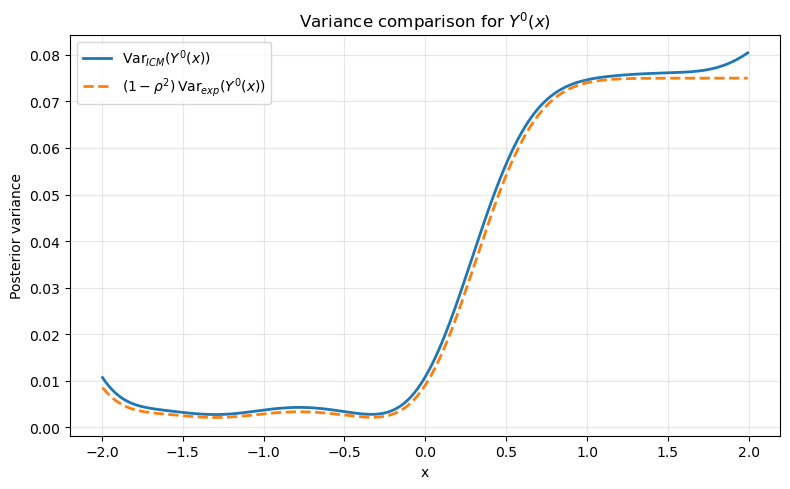

In [8]:
import matplotlib.pyplot as plt

scaled_exp_var0 = (1 - rho**2) * var_Y0_exp_only

plt.figure(figsize=(8,5))

plt.plot(test_X.flatten(), var_Y0_causalICM, 
         label=r"$\mathrm{Var}_{ICM}(Y^0(x))$", lw=2)

plt.plot(test_X.flatten(), scaled_exp_var0, 
         label=r"$(1-\rho^2)\,\mathrm{Var}_{exp}(Y^0(x))$", 
         lw=2, linestyle="--")

plt.xlabel("x")
plt.ylabel("Posterior variance")
plt.title("Variance comparison for $Y^0(x)$")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


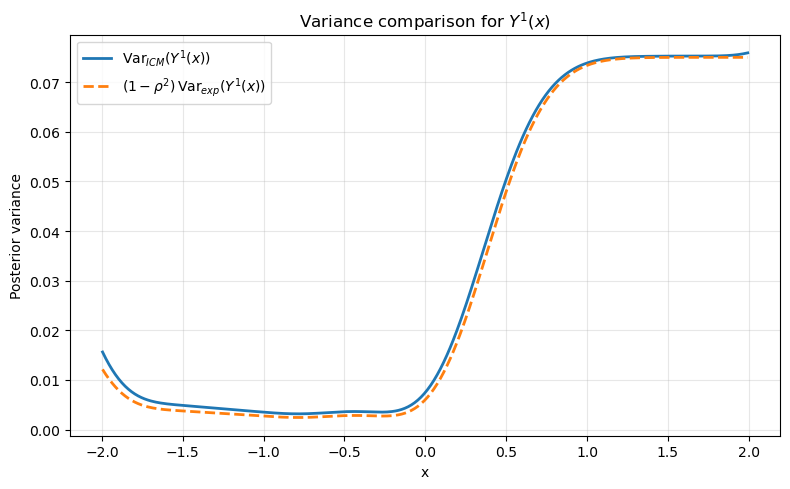

In [9]:
scaled_exp_var_Y1 = (1 - rho**2) * var_Y1_exp_only

plt.figure(figsize=(8,5))

plt.plot(test_X.flatten(), var_Y1_causalICM, 
         label=r"$\mathrm{Var}_{ICM}(Y^1(x))$", lw=2)

plt.plot(test_X.flatten(), scaled_exp_var_Y1, 
         label=r"$(1-\rho^2)\,\mathrm{Var}_{exp}(Y^1(x))$", 
         lw=2, linestyle="--")

plt.xlabel("x")
plt.ylabel("Posterior variance")
plt.title("Variance comparison for $Y^1(x)$")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


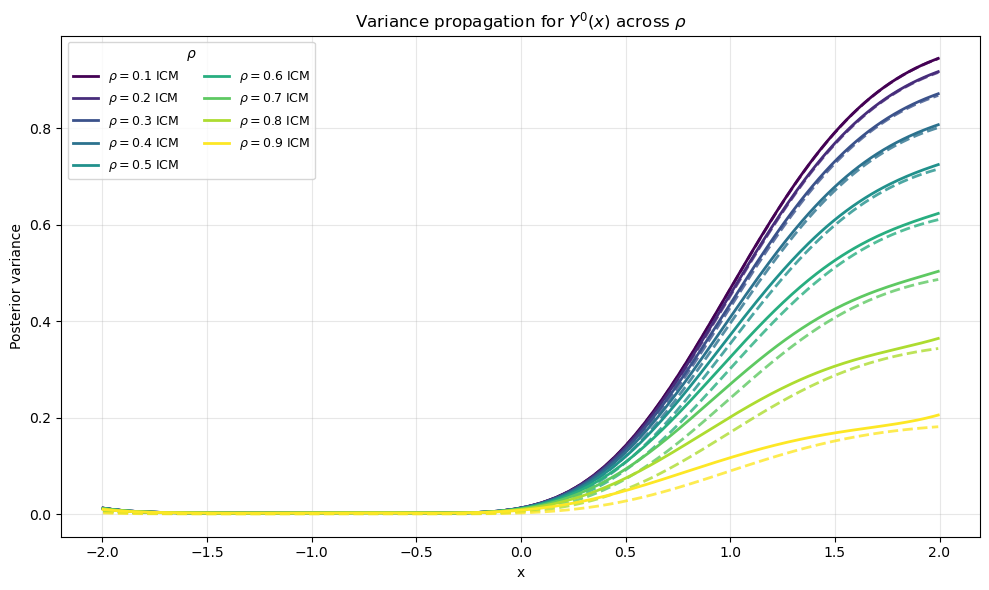

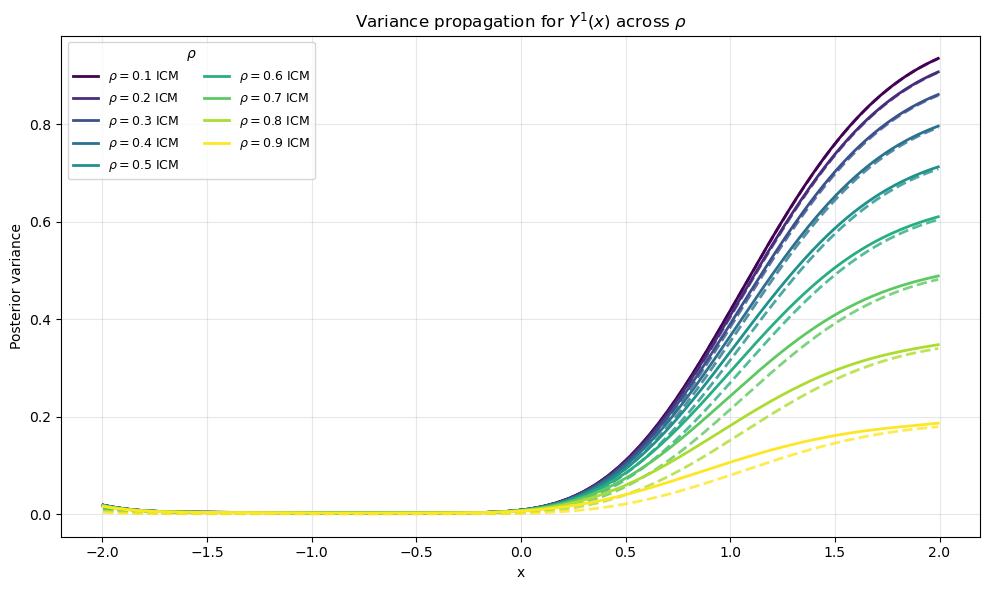

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor, cho_solve
import matplotlib.cm as cm

# ============================================================
# Hyperparameters
# ============================================================
ell = np.array([1.0])     # lengthscale
sigma_f2 = 1.0            # signal variance
sigma2 = 0.1              # noise variance

# ============================================================
# RBF Kernel
# ============================================================
def rbf_kernel(x, y, ell, var):
    x = np.atleast_2d(x)
    y = np.atleast_2d(y)
    dists = ((x[:, None, :] - y[None, :, :])**2) / ell**2
    return var * np.exp(-0.5 * np.sum(dists, axis=2))

# ============================================================
# Experimental GP posterior
# ============================================================
def gp_posterior_exp(X_train, Y_train, X_star):
    K = rbf_kernel(X_train, X_train, ell, sigma_f2) + sigma2 * np.eye(len(X_train))
    cho = cho_factor(K, lower=True)

    K_star = rbf_kernel(X_star, X_train, ell, sigma_f2)
    mu = K_star @ cho_solve(cho, Y_train)

    K_ss = rbf_kernel(X_star, X_star, ell, sigma_f2)
    var = np.diag(K_ss - K_star @ cho_solve(cho, K_star.T))

    return mu, var, cho

# ============================================================
# ICM posterior variance
# ============================================================
def icm_posterior_var(X_star, X_exp, Y_exp, X_obs, rho):

    _, _, cho_e = gp_posterior_exp(X_exp, Y_exp, X_star)

    K_xe = rbf_kernel(X_star, X_exp, ell, sigma_f2)
    K_xx = rbf_kernel(X_star, X_star, ell, sigma_f2)
    var_e = np.diag(K_xx - K_xe @ cho_solve(cho_e, K_xe.T))

    K_xo = rbf_kernel(X_star, X_obs, ell, sigma_f2)
    K_eo = rbf_kernel(X_exp, X_obs, ell, sigma_f2)
    K_oe = K_eo.T

    Kprime_xo = K_xe @ cho_solve(cho_e, K_eo)
    Kprime_oo = K_oe @ cho_solve(cho_e, K_eo)

    K_oo = rbf_kernel(X_obs, X_obs, ell, sigma_f2)
    Sigma = K_oo - rho**2 * Kprime_oo + sigma2 * np.eye(len(X_obs))
    cho_o = cho_factor(Sigma, lower=True)

    cross = rho * (K_xo - Kprime_xo)
    reduction = np.diag(cross @ cho_solve(cho_o, cross.T))

    return var_e, reduction, var_e - reduction

# ============================================================
# >>> YOU MUST ALREADY HAVE THESE ARRAYS DEFINED <<<
# test_X, X0_exp, Y0_exp, X0_obs, Y0_obs
# test_X, X1_exp, Y1_exp, X1_obs, Y1_obs
# ============================================================

# ============================================================
# Rho grid
# ============================================================
rhos = np.arange(0.1, 1.0, 0.1)
colors = cm.viridis(np.linspace(0, 1, len(rhos)))

# ============================================================
# PLOT: Y0 ARM
# ============================================================
plt.figure(figsize=(10, 6))

for i, rho in enumerate(rhos):

    var_Y0_exp_only, _, var_Y0_causalICM = icm_posterior_var(
        test_X, X0_exp, Y0_exp, X0_obs, rho
    )

    scaled_exp_var0 = (1 - rho**2) * var_Y0_exp_only

    plt.plot(test_X.flatten(), var_Y0_causalICM,
             color=colors[i], lw=2,
             label=fr"$\rho={rho:.1f}$ ICM")

    plt.plot(test_X.flatten(), scaled_exp_var0,
             color=colors[i], lw=2, ls="--", alpha=0.8)

plt.xlabel("x")
plt.ylabel("Posterior variance")
plt.title(r"Variance propagation for $Y^0(x)$ across $\rho$")
plt.grid(alpha=0.3)

handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), title=r"$\rho$", ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================
# PLOT: Y1 ARM
# ============================================================
plt.figure(figsize=(10, 6))

for i, rho in enumerate(rhos):

    var_Y1_exp_only, _, var_Y1_causalICM = icm_posterior_var(
        test_X, X1_exp, Y1_exp, X1_obs, rho
    )

    scaled_exp_var1 = (1 - rho**2) * var_Y1_exp_only

    plt.plot(test_X.flatten(), var_Y1_causalICM,
             color=colors[i], lw=2,
             label=fr"$\rho={rho:.1f}$ ICM")

    plt.plot(test_X.flatten(), scaled_exp_var1,
             color=colors[i], lw=2, ls="--", alpha=0.8)

plt.xlabel("x")
plt.ylabel("Posterior variance")
plt.title(r"Variance propagation for $Y^1(x)$ across $\rho$")
plt.grid(alpha=0.3)

handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), title=r"$\rho$", ncol=2, fontsize=9)

plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
import numpy as np

# Define rhos
rhos = np.arange(0.1, 1.0, 0.1)

# Experimental-only variance (independent of rho)
var_Y0_exp_only_base, _, _ = icm_posterior_var(test_X, X0_exp, Y0_exp, X0_obs, rho=0.0)
var_Y1_exp_only_base, _, _ = icm_posterior_var(test_X, X1_exp, Y1_exp, X1_obs, rho=0.0)

# Prepare lists to store flattened results
records_Y0 = []
records_Y1 = []

for rho in rhos:
    # Compute causal ICM variance for this rho
    _, _, var_Y0_causalICM = icm_posterior_var(test_X, X0_exp, Y0_exp, X0_obs, rho)
    _, _, var_Y1_causalICM = icm_posterior_var(test_X, X1_exp, Y1_exp, X1_obs, rho)
    
    # Scaled experimental-only variance
    scaled_var_Y0_exp = (1 - rho**2) * var_Y0_exp_only_base
    scaled_var_Y1_exp = (1 - rho**2) * var_Y1_exp_only_base
    
    # Flatten results per x
    for xi, icm_var0, exp_var0, icm_var1, exp_var1 in zip(
        test_X.flatten(),
        var_Y0_causalICM,
        scaled_var_Y0_exp,
        var_Y1_causalICM,
        scaled_var_Y1_exp
    ):
        records_Y0.append({
            "rho": rho,
            "x": xi,
            "ICM_var": icm_var0,
            "scaled_exp_var": exp_var0
        })
        records_Y1.append({
            "rho": rho,
            "x": xi,
            "ICM_var": icm_var1,
            "scaled_exp_var": exp_var1
        })

# Convert to DataFrames
df_Y0 = pd.DataFrame(records_Y0)
df_Y1 = pd.DataFrame(records_Y1)

# Optional: quick check
print(df_Y0.head())
print(df_Y1.head())


   rho         x   ICM_var  scaled_exp_var
0  0.1 -1.996014  0.012525        0.012417
1  0.1 -1.986014  0.011851        0.011748
2  0.1 -1.976014  0.011214        0.011115
3  0.1 -1.966014  0.010613        0.010519
4  0.1 -1.956014  0.010047        0.009958
   rho         x   ICM_var  scaled_exp_var
0  0.1 -1.996014  0.018642        0.018475
1  0.1 -1.986014  0.017708        0.017549
2  0.1 -1.976014  0.016821        0.016669
3  0.1 -1.966014  0.015978        0.015834
4  0.1 -1.956014  0.015179        0.015041


In [12]:
# Save to CSV
df_Y0.to_csv("variance_bound_results_Y0.csv", index=False)
df_Y1.to_csv("variance_bound_results_Y1.csv", index=False)

# Different sample sizes

In [13]:
import numpy as np
import pandas as pd

# Observational sample sizes to test
obs_sample_sizes = [200, 500, 1000, 2000]
exp_sample_size = 200
rhos = np.arange(0.1, 1.0, 0.1)

# Lists to store all results
all_records_Y0 = []
all_records_Y1 = []

for n_obs in obs_sample_sizes:
    print(f"Running simulation for observational sample size = {n_obs}")
    
    # 1. Simulate data
    data_exp, data_obs = data_simulation(sample_size_rct=exp_sample_size, sample_size_obs=n_obs)
    
    # 2. Split by treatment
    X0_exp = data_exp[data_exp[:,2] == 0][:,1:2]
    Y0_exp = data_exp[data_exp[:,2] == 0][:,3]

    X1_exp = data_exp[data_exp[:,2] == 1][:,1:2]
    Y1_exp = data_exp[data_exp[:,2] == 1][:,3]

    X0_obs = data_obs[data_obs[:,2] == 0][:,1:2]
    Y0_obs = data_obs[data_obs[:,2] == 0][:,3]

    X1_obs = data_obs[data_obs[:,2] == 1][:,1:2]
    Y1_obs = data_obs[data_obs[:,2] == 1][:,3]

    # 3. Test grid
    test_X = np.arange(np.min(np.r_[data_exp[:,1],data_obs[:,1]]),
                       np.max(np.r_[data_exp[:,1],data_obs[:,1]]), 0.01).reshape(-1,1)

    # 4. Experimental-only variance (rho=0)
    var_Y0_exp_only_base, _, _ = icm_posterior_var(test_X, X0_exp, Y0_exp, X0_obs, rho=0.0)
    var_Y1_exp_only_base, _, _ = icm_posterior_var(test_X, X1_exp, Y1_exp, X1_obs, rho=0.0)

    # 5. Loop over rhos
    for rho in rhos:
        # Causal ICM variances
        _, _, var_Y0_causalICM = icm_posterior_var(test_X, X0_exp, Y0_exp, X0_obs, rho)
        _, _, var_Y1_causalICM = icm_posterior_var(test_X, X1_exp, Y1_exp, X1_obs, rho)

        # Scaled experimental-only variances
        scaled_var_Y0_exp = (1 - rho**2) * var_Y0_exp_only_base
        scaled_var_Y1_exp = (1 - rho**2) * var_Y1_exp_only_base

        # Flatten results per x and store
        for xi, icm_var0, exp_var0, icm_var1, exp_var1 in zip(
            test_X.flatten(),
            var_Y0_causalICM,
            scaled_var_Y0_exp,
            var_Y1_causalICM,
            scaled_var_Y1_exp
        ):
            all_records_Y0.append({
                "obs_sample_size": n_obs,
                "rho": rho,
                "x": xi,
                "ICM_var": icm_var0,
                "scaled_exp_var": exp_var0
            })
            all_records_Y1.append({
                "obs_sample_size": n_obs,
                "rho": rho,
                "x": xi,
                "ICM_var": icm_var1,
                "scaled_exp_var": exp_var1
            })

# 6. Convert to DataFrames
df_Y0_all = pd.DataFrame(all_records_Y0)
df_Y1_all = pd.DataFrame(all_records_Y1)



print("Simulation complete. DataFrames created:")
print(df_Y0_all.head())
print(df_Y1_all.head())


Running simulation for observational sample size = 200
Running simulation for observational sample size = 500
Running simulation for observational sample size = 1000
Running simulation for observational sample size = 2000
Simulation complete. DataFrames created:
   obs_sample_size  rho         x   ICM_var  scaled_exp_var
0              200  0.1 -1.990521  0.010744        0.010643
1              200  0.1 -1.980521  0.010163        0.010067
2              200  0.1 -1.970521  0.009616        0.009525
3              200  0.1 -1.960521  0.009102        0.009016
4              200  0.1 -1.950521  0.008620        0.008538
   obs_sample_size  rho         x   ICM_var  scaled_exp_var
0              200  0.1 -1.990521  0.010207        0.010109
1              200  0.1 -1.980521  0.009621        0.009528
2              200  0.1 -1.970521  0.009073        0.008985
3              200  0.1 -1.960521  0.008561        0.008478
4              200  0.1 -1.950521  0.008085        0.008007


In [14]:
# 7. Optional: save to CSV
df_Y0_all.to_csv("variance_bound_results_Y0_all_sample_sizes.csv", index=False)
df_Y1_all.to_csv("variance_bound_results_Y1_all_sample_sizes.csv", index=False)

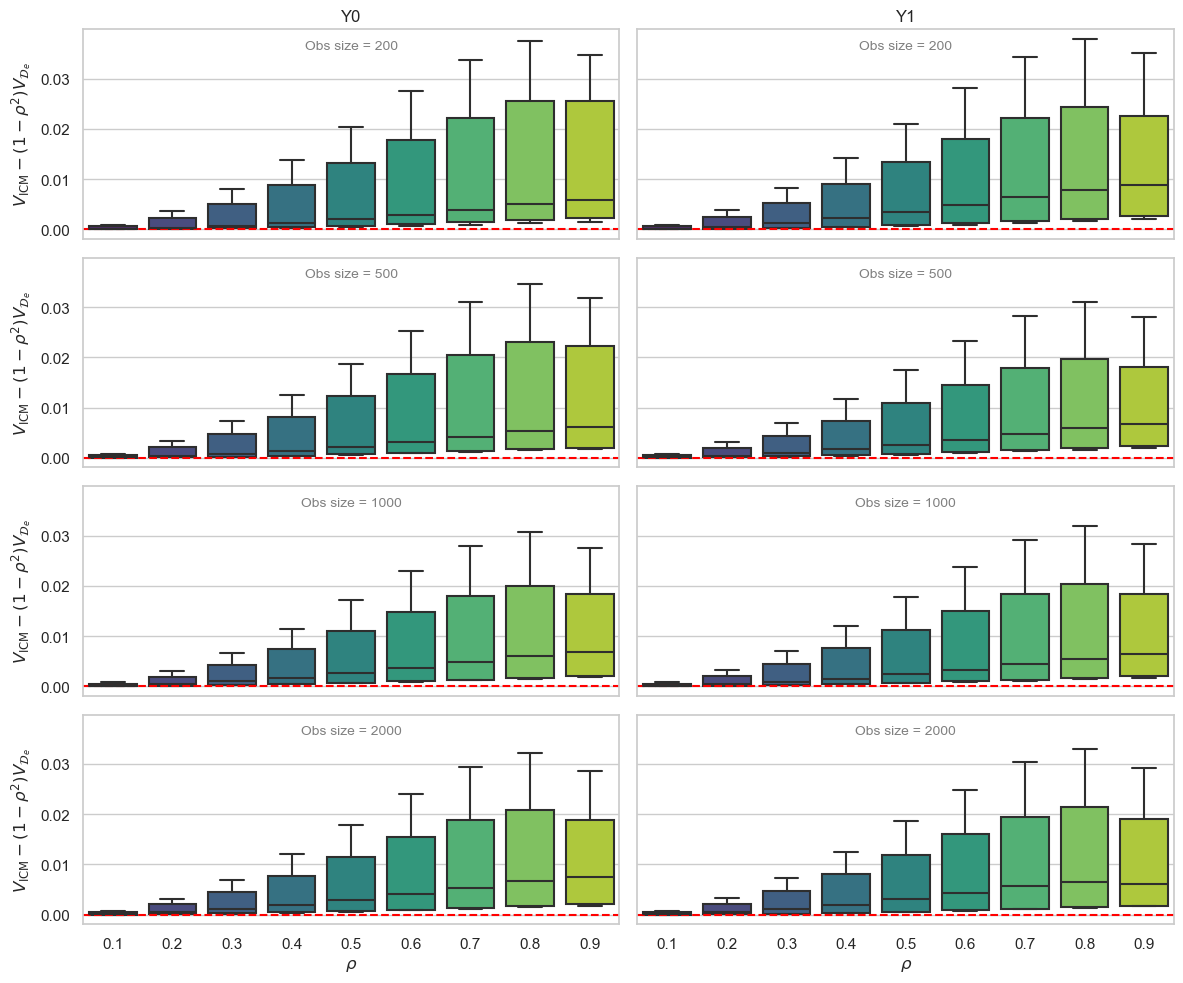

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define sample sizes and arms
obs_sizes = [200, 500, 1000, 2000]
arms = ['Y0', 'Y1']

fig, axes = plt.subplots(len(obs_sizes), len(arms), figsize=(12, 10), sharey=True, sharex=True)

# Ensure axes is 2D
if len(obs_sizes) == 1:
    axes = axes[np.newaxis, :]
if len(arms) == 1:
    axes = axes[:, np.newaxis]

for j, arm in enumerate(arms):
    for i, obs_size in enumerate(obs_sizes):
        ax = axes[i, j]
        # Filter data for this obs size and arm
        df_plot = df_diff_all[(df_diff_all['obs_sample_size'] == obs_size) &
                              (df_diff_all['Arm'] == arm)]
        
        # Boxplot
        sns.boxplot(x='rho', y='Variance_diff', data=df_plot, palette="viridis", ax=ax)
        ax.axhline(0, color='red', linestyle='--', lw=1.5)
        
        # Set x-ticks to the actual rho values
        unique_rhos = np.round(sorted(df_plot['rho'].unique()), 1)
        ax.set_xticks(range(len(unique_rhos)))
        ax.set_xticklabels([f"{r:.1f}" for r in unique_rhos])
        
        # Column title for arms
        if i == 0:
            ax.set_title(arm, fontsize=12)
        
        # Subtitle for obs size
        ax.text(0.5, 0.95, f"Obs size = {obs_size}", transform=ax.transAxes,
                ha='center', va='top', fontsize=10, color='gray')
        
        # Only bottom row has x-label
        if i == len(obs_sizes) - 1:
            ax.set_xlabel(r"$\rho$")
        else:
            ax.set_xlabel('')
        
        # Only left column has y-label
        if j == 0:
            ax.set_ylabel(r"$V_{\mathrm{ICM}} - (1-\rho^2)V_{\mathcal{D}_e}$")
        else:
            ax.set_ylabel('')

plt.tight_layout()
plt.show()
